In [18]:
# ── Core data libraries
import pandas as pd
import numpy as np

# ── Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings
pd.set_option('display.max_columns', None)    # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120

In [19]:
df=pd.read_csv("german_credit_data.csv")
Shape=df.shape
print("Shape:", Shape)
df.head()

Shape: (1000, 21)


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,4,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,2,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,3,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,4,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,4,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


## Target Distribution

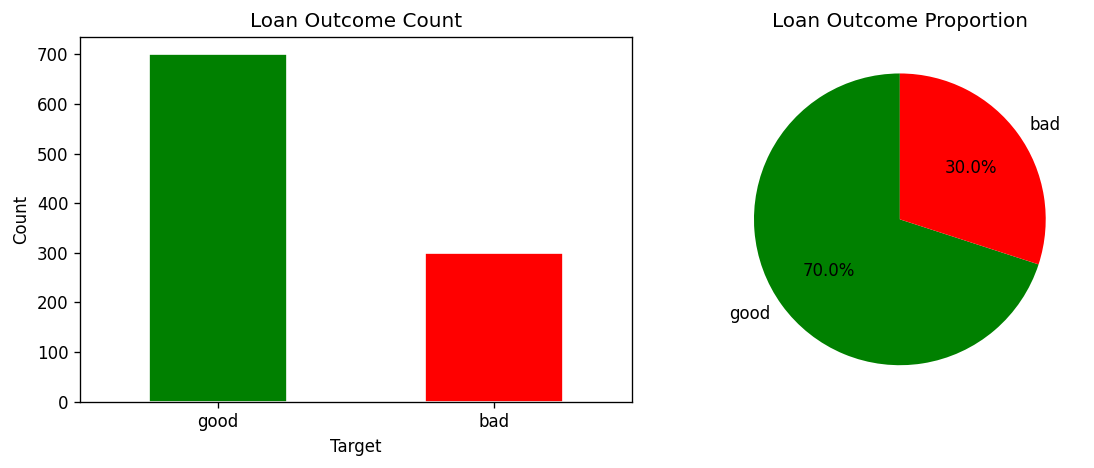

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
df['target'].value_counts().plot(kind='bar', ax=axes[0], 
                                  color=['green', 'red'], 
                                  edgecolor='white', width=0.5)
axes[0].set_title('Loan Outcome Count')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1],
                                  colors=['green', 'red'],
                                  autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Loan Outcome Proportion')

plt.tight_layout()
plt.show()

## Numeric Features Distribution

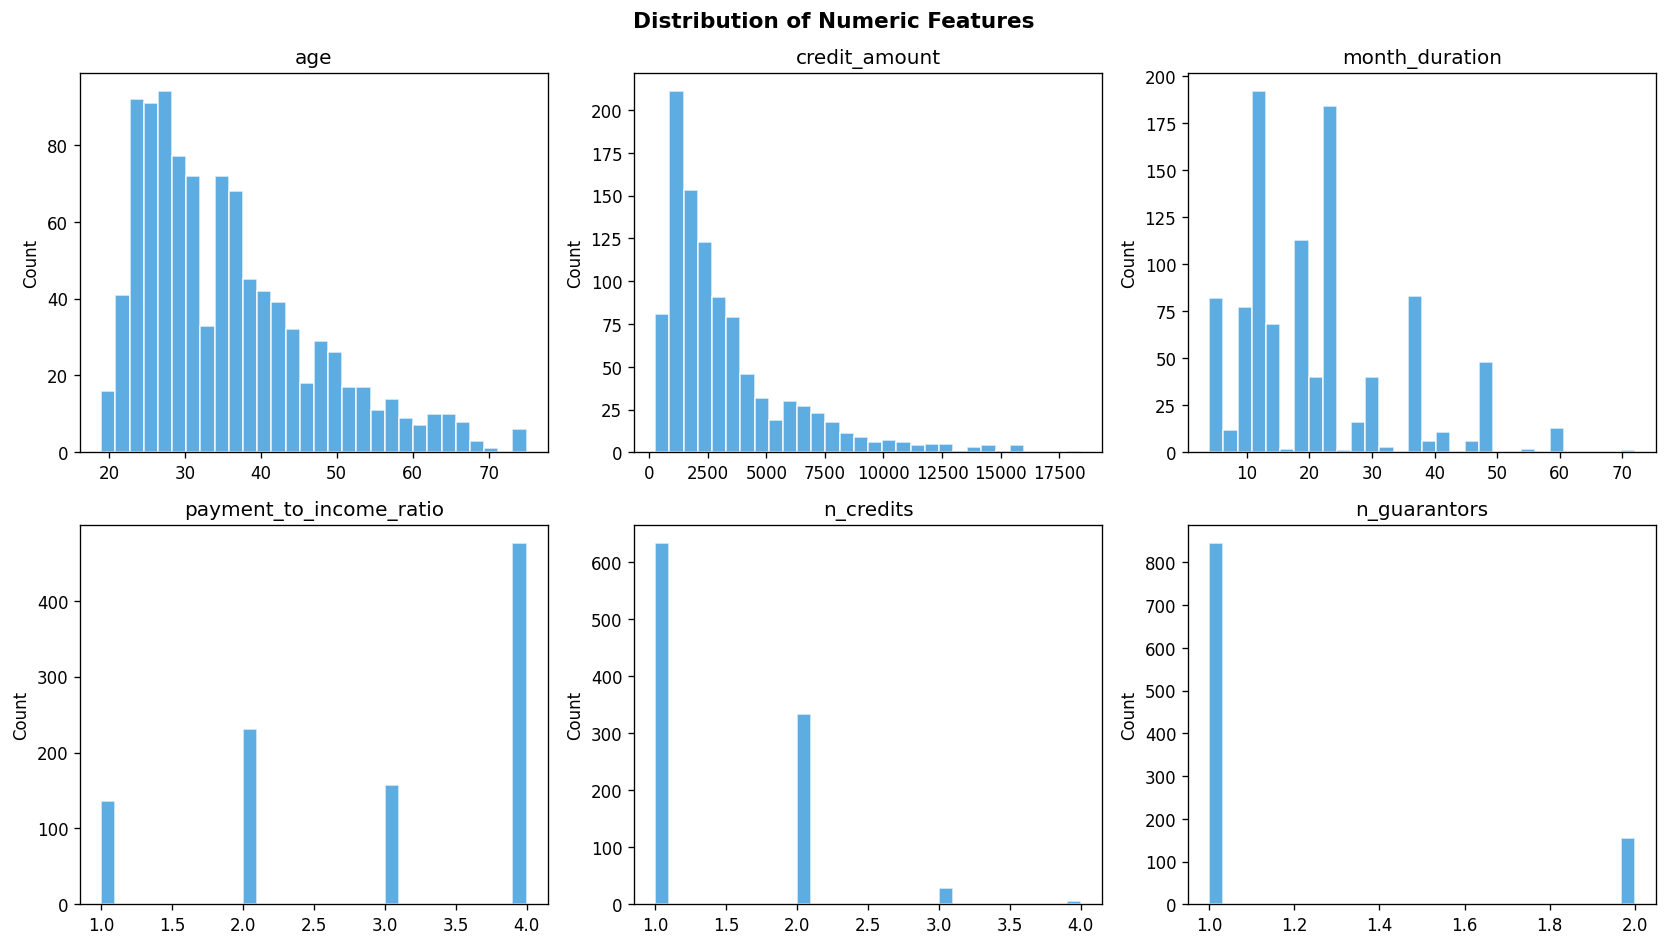

In [27]:
numeric_cols = ['age', 'credit_amount', 'month_duration', 
                'payment_to_income_ratio', 'n_credits', 'n_guarantors']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Age — most borrowers are young (25–40). 
#### Right-skewed, meaning a long tail of older applicants.
#### Credit amount — also right-skewed. 
#### Most loans are small but a few are very large. This is typical in microfinance.
#### Month duration — most loans are short-term (12–24 months).
#### Payment to income ratio — heavily concentrated at 1–4, meaning most people pay 1–4% of income as installments.
#### n_credits & n_guarantors — almost everyone has 1, so these may not be very informative features.

## Default Rate by Key Categorical Features

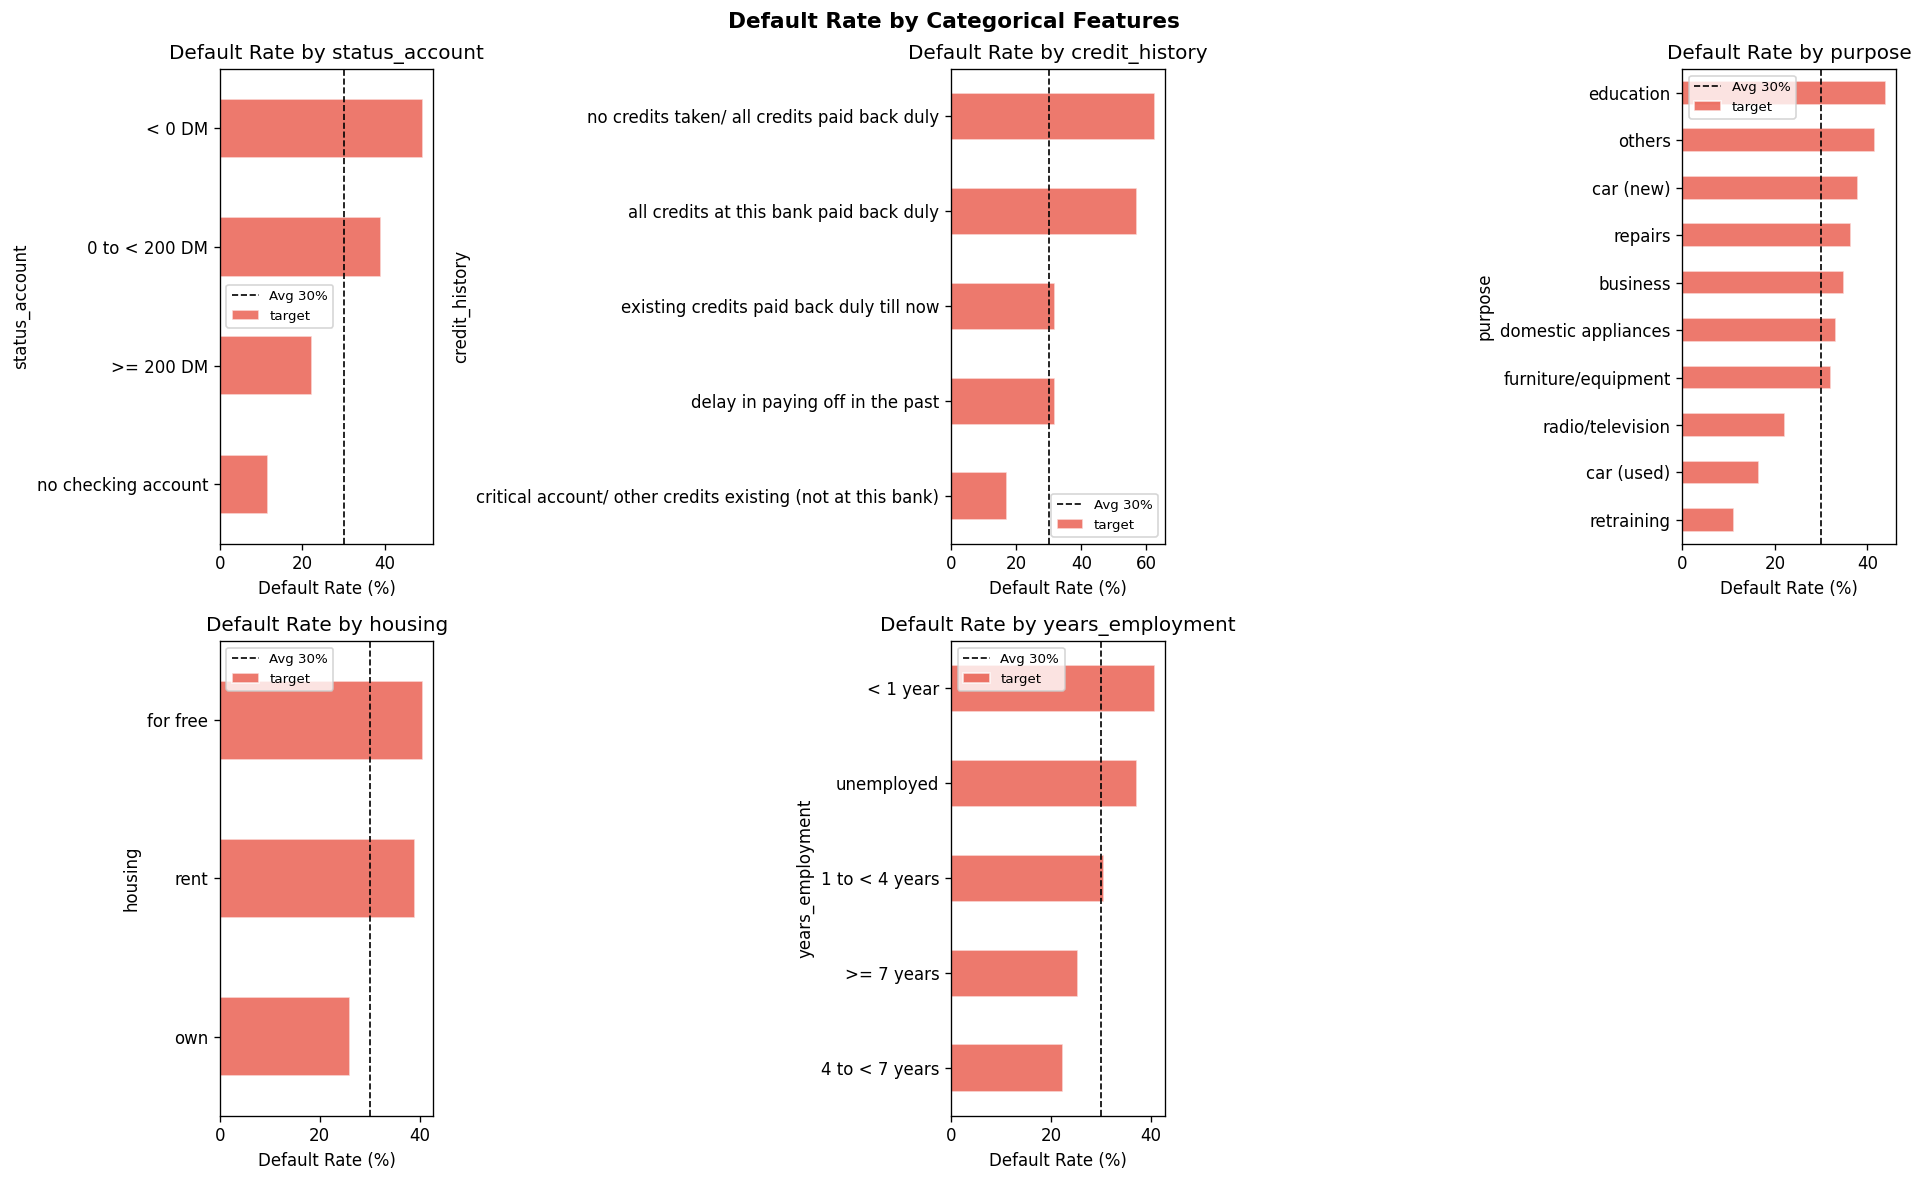

In [28]:
cat_cols = ['status_account', 'credit_history', 'purpose', 
            'housing', 'years_employment']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['target'].apply(
        lambda x: (x == 'bad').mean() * 100
    ).sort_values(ascending=True)
    
    default_rate.plot(kind='barh', ax=axes[i], color='#e74c3c', 
                      alpha=0.75, edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].axvline(30, color='black', linestyle='--', lw=1, label='Avg 30%')
    axes[i].legend(fontsize=8)

axes[5].axis('off')  # hide the empty 6th subplot
plt.suptitle('Default Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Status account — applicants with no checking account or balances below 0 DM default at the highest rates. Having a healthy checking account is one of the strongest signals of creditworthiness.
#### Credit history — borrowers with a critical account history or no credits taken have very high default rates. Applicants who have paid back credits duly default far less.
#### Purpose — retraining and other/unknown purposes are riskiest. Car and radio/TV purchases are safer.
#### Housing — people paying rent default more than homeowners, which makes intuitive sense.
#### Years employed — unemployed applicants default at the highest rate by far. Longer employment = lower default risk.



## Age & Credit Amount vs Default

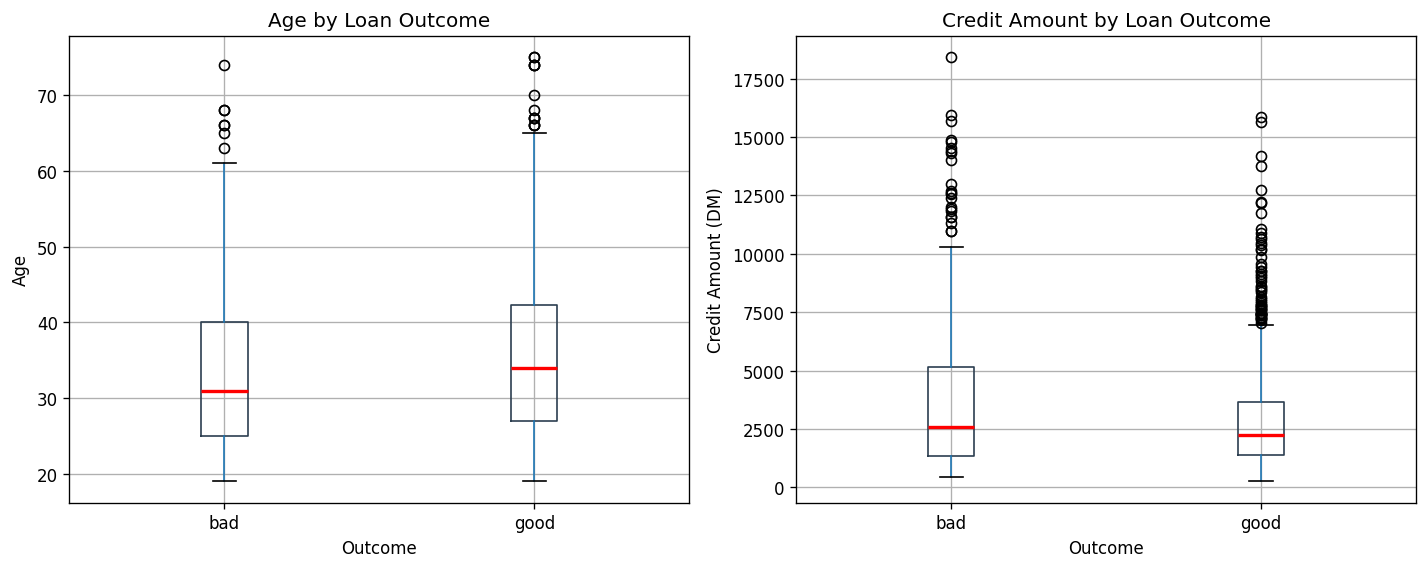

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age by target
df.boxplot(column='age', by='target', ax=axes[0],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red', lw=2))
axes[0].set_title('Age by Loan Outcome')
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('Age')

# Credit amount by target
df.boxplot(column='credit_amount', by='target', ax=axes[1],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red', lw=2))
axes[1].set_title('Credit Amount by Loan Outcome')
axes[1].set_xlabel('Outcome'); axes[1].set_ylabel('Credit Amount (DM)')

plt.suptitle('')
plt.tight_layout()
plt.show()

#### Age — the median age of defaulters is slightly lower than good payers. Younger applicants carry more risk, which aligns with less financial stability early in a career.
#### Credit amount — defaulters tend to borrow larger amounts. The median loan for bad applicants is higher than for good ones. Larger loans = higher default risk, which is intuitive.

## Encode the Target Variable

In [30]:
df['target'] = df['target'].map({'good': 0, 'bad': 1})

print(df['target'].value_counts())
print(f"\nDefault rate: {df['target'].mean():.2%}")

target
0    700
1    300
Name: count, dtype: int64

Default rate: 30.00%


## Separate Numeric and Categorical Columns

In [31]:
numeric_cols = ['age', 'credit_amount', 'month_duration',
                'payment_to_income_ratio', 'residence_since',
                'n_credits', 'n_guarantors']

categorical_cols = ['status_account', 'credit_history', 'purpose',
                    'status_savings', 'years_employment', 'status_and_sex',
                    'secondary_obligor', 'collateral', 'other_installment_plans',
                    'housing', 'job', 'telephone', 'is_foreign_worker']

print(f"Numeric features   : {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features   : 7
Categorical features: 13


## Check Cardinality of Categorical Columns

In [32]:
print(f"{'Column':<30} {'Unique Values':<15} {'Values'}")
print("-" * 80)
for col in categorical_cols:
    vals = df[col].unique()
    print(f"{col:<30} {len(vals):<15} {list(vals)}")

Column                         Unique Values   Values
--------------------------------------------------------------------------------
status_account                 4               ['< 0 DM', '0 to < 200 DM', 'no checking account', '>= 200 DM']
credit_history                 5               ['critical account/ other credits existing (not at this bank)', 'existing credits paid back duly till now', 'delay in paying off in the past', 'no credits taken/ all credits paid back duly', 'all credits at this bank paid back duly']
purpose                        10              ['radio/television', 'education', 'furniture/equipment', 'car (new)', 'car (used)', 'business', 'domestic appliances', 'repairs', 'others', 'retraining']
status_savings                 5               ['unknown/ no savings account', '< 100 DM', '500 to < 1000 DM', '>= 1000 DM', '100 to < 500 DM']
years_employment               5               ['>= 7 years', '1 to < 4 years', '4 to < 7 years', 'unemployed', '< 1 year']
stat

## Ordinal Encoding (order-preserving)

In [33]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct order for each ordinal column
ordinal_mappings = {
    'status_account': [
        '< 0 DM',
        '0 to < 200 DM',
        '>= 200 DM',
        'no checking account'
    ],
    'status_savings': [
        '< 100 DM',
        '100 to < 500 DM',
        '500 to < 1000 DM',
        '>= 1000 DM',
        'unknown/ no savings account'
    ],
    'years_employment': [
        'unemployed',
        '< 1 year',
        '1 to < 4 years',
        '4 to < 7 years',
        '>= 7 years'
    ],
    'credit_history': [
        'critical account/ other credits existing (not at this bank)',
        'delay in paying off in the past',
        'existing credits paid back duly till now',
        'all credits at this bank paid back duly',
        'no credits taken/ all credits paid back duly'
    ]
}

for col, order in ordinal_mappings.items():
    mapping = {val: i for i, val in enumerate(order)}
    df[col] = df[col].map(mapping)

print("Ordinal encoding done:")
print(df[['status_account','status_savings',
          'years_employment','credit_history']].head())

Ordinal encoding done:
   status_account  status_savings  years_employment  credit_history
0               0               4                 4               0
1               1               0                 2               2
2               3               0                 3               0
3               0               0                 3               2
4               0               0                 2               1


## Binary Encoding

In [34]:
df['telephone']       = df['telephone'].map(
    {'yes, registered under the customers name': 1, 'none': 0})

df['is_foreign_worker'] = df['is_foreign_worker'].map({'yes': 1, 'no': 0})

print("Binary encoding done:")
print(df[['telephone', 'is_foreign_worker']].head())

Binary encoding done:
   telephone  is_foreign_worker
0          1                  1
1          0                  1
2          0                  1
3          0                  1
4          0                  1


## One-Hot Encoding (remaining categoricals)

In [35]:
ohe_cols = ['purpose', 'status_and_sex', 'secondary_obligor',
            'collateral', 'other_installment_plans', 'housing', 'job']

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape after encoding: (1000, 38)
Columns: ['status_account', 'month_duration', 'credit_history', 'credit_amount', 'status_savings', 'years_employment', 'payment_to_income_ratio', 'residence_since', 'age', 'n_credits', 'n_guarantors', 'telephone', 'is_foreign_worker', 'target', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_others', 'purpose_radio/television', 'purpose_repairs', 'purpose_retraining', 'status_and_sex_male : divorced/separated', 'status_and_sex_male : married/widowed', 'status_and_sex_male : single', 'secondary_obligor_guarantor', 'secondary_obligor_none', 'collateral_none', 'collateral_real estate', 'collateral_savings agreement/life insurance', 'other_installment_plans_none', 'other_installment_plans_stores', 'housing_own', 'housing_rent', 'job_skilled employee/ official', 'job_unemployed/ unskilled - non-resident', 'job_unskilled - resident']


## Feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'credit_amount', 'month_duration',
                'payment_to_income_ratio', 'residence_since',
                'n_credits', 'n_guarantors']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaling done. Sample of scaled values:")
print(df[numeric_cols].head())

Scaling done. Sample of scaled values:
    age  credit_amount  month_duration  payment_to_income_ratio  \
0  2.77          -0.75           -1.24                     0.92   
1 -1.19           0.95            2.25                    -0.87   
2  1.18          -0.42           -0.74                    -0.87   
3  0.83           1.63            1.75                    -0.87   
4  1.54           0.57            0.26                     0.02   

   residence_since  n_credits  n_guarantors  
0             1.05       1.03         -0.43  
1            -0.77      -0.70         -0.43  
2             0.14      -0.70          2.33  
3             1.05      -0.70          2.33  
4             1.05       1.03          2.33  


## Split Features and Target

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Default rate in full dataset:", round(y.mean() * 100, 2), "%")

X shape: (1000, 37)
y shape: (1000,)
Default rate in full dataset: 30.0 %


## Train/Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows  :", X_train.shape[0])
print("Testing rows   :", X_test.shape[0])
print("Default rate (train):", round(y_train.mean() * 100, 2), "%")
print("Default rate (test) :", round(y_test.mean() * 100, 2), "%")

Training rows  : 750
Testing rows   : 250
Default rate (train): 30.0 %
Default rate (test) : 30.0 %


## Train Three Models

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.05,
                                          eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_prob': y_prob, 'auc': auc}
    print("Model:", name, "| AUC:", round(auc, 4))

Model: Logistic Regression | AUC: 0.8098
Model: Random Forest | AUC: 0.809
Model: XGBoost | AUC: 0.8154


## Cross Validation (confirming the score is real, not lucky)

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, res in results.items():
    cv_scores = cross_val_score(res['model'], X_train, y_train,
                                cv=cv, scoring='roc_auc')
    print("Model:", name)
    print("  CV AUC scores:", [round(s, 4) for s in cv_scores])
    print("  Mean CV AUC  :", round(cv_scores.mean(), 4))
    print("  Std          :", round(cv_scores.std(), 4))
    print()

Model: Logistic Regression
  CV AUC scores: [np.float64(0.7283), np.float64(0.7862), np.float64(0.811), np.float64(0.8099), np.float64(0.7579)]
  Mean CV AUC  : 0.7787
  Std          : 0.0318

Model: Random Forest
  CV AUC scores: [np.float64(0.7611), np.float64(0.7834), np.float64(0.7751), np.float64(0.8043), np.float64(0.7786)]
  Mean CV AUC  : 0.7805
  Std          : 0.014

Model: XGBoost
  CV AUC scores: [np.float64(0.7145), np.float64(0.7437), np.float64(0.8034), np.float64(0.7985), np.float64(0.763)]
  Mean CV AUC  : 0.7646
  Std          : 0.0335



## Hyperparameter Tuning
### Tune XGBoost with GridSearchCV

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = 'roc_auc',
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("Best parameters :", grid_search.best_params_)
print("Best CV AUC     :", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best CV AUC     : 0.7958


##  Combine XGBoost + Logistic Regression (Ensemble)

## Train XGBoost and get its probabilities:

In [43]:
from xgboost import XGBClassifier

best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

best_xgb.fit(X_train, y_train)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost trained")
print("y_prob_xgb sample:", y_prob_xgb[:5].round(4))

XGBoost trained
y_prob_xgb sample: [0.7466 0.0993 0.0991 0.1105 0.1976]


## Train Logistic Regression and get its probabilities:

In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression trained")
print("y_prob_lr sample:", y_prob_lr[:5].round(4))

Logistic Regression trained
y_prob_lr sample: [0.9027 0.0709 0.0805 0.05   0.2969]


##  Now blend them:

In [45]:
# Average the probabilities from two models
y_prob_ensemble = (y_prob_xgb * 0.6) + (y_prob_lr * 0.4)

print("Ensemble probabilities created")
print("Sample:", y_prob_ensemble[:5].round(4))

Ensemble probabilities created
Sample: [0.809  0.088  0.0917 0.0863 0.2373]


## Compare all three:

In [46]:
from sklearn.metrics import roc_auc_score

print("XGBoost AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))
print("LR AUC       :", round(roc_auc_score(y_test, y_prob_lr), 4))
print("Ensemble AUC :", round(roc_auc_score(y_test, y_prob_ensemble), 4))

XGBoost AUC  : 0.7986
LR AUC       : 0.8101
Ensemble AUC : 0.8076


## ROC Curve

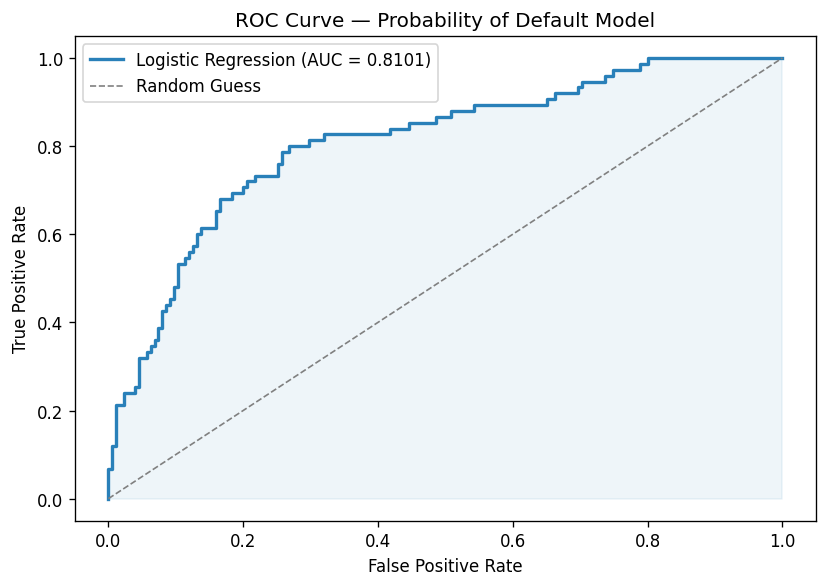

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2980b9', lw=2,
         label='Logistic Regression (AUC = ' + str(round(auc_score, 4)) + ')')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Guess')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2980b9')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Probability of Default Model')
plt.legend()
plt.tight_layout()
plt.show()

## Confusion Matrix

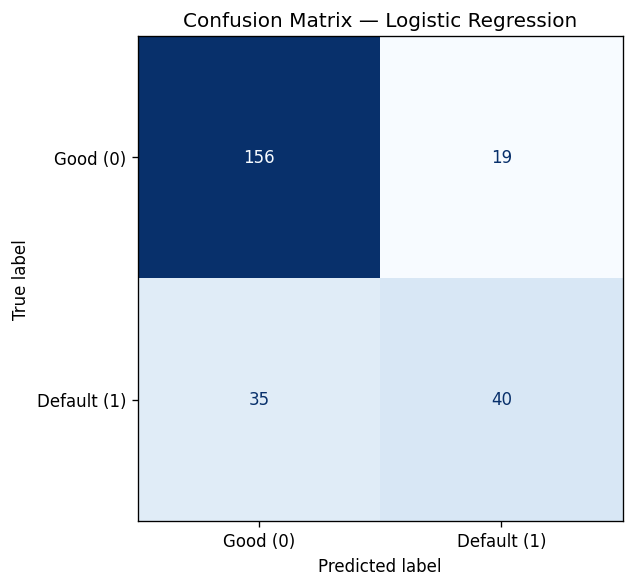

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = (y_prob_lr >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Good (0)', 'Default (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
ax.grid(False)
plt.tight_layout()
plt.show()

## Expected Loss Calculation

In [50]:
# ── Pull original credit amounts back from the raw file
df_raw = pd.read_csv('german_credit_data.csv')
EAD = df_raw.loc[y_test.index, 'credit_amount'].values

# ── The three components
PD  = y_prob_lr          # model output — probability of default per borrower
LGD = 0.45               # Basel II standard for unsecured retail loans
# EAD = loan amount already defined above

# ── Expected Loss formula
EL = PD * LGD * EAD

# ── Build results table
el_df = pd.DataFrame({
    'PD'              : PD.round(4),
    'LGD'             : LGD,
    'EAD'             : EAD,
    'Expected_Loss'   : EL.round(2),
    'Actual_Default'  : y_test.values,
    'Risk_Band'       : pd.cut(PD,
                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                          labels=['Very Low','Low','Medium','High','Very High'])
})

# ── Portfolio summary
print("=" * 50)
print("PORTFOLIO EXPECTED LOSS SUMMARY")
print("=" * 50)
print("Total Exposure (EAD) :", "DM", f"{EAD.sum():,.0f}")
print("Total Expected Loss  :", "DM", f"{EL.sum():,.0f}")
print("Portfolio EL Rate    :", str(round((EL.sum() / EAD.sum()) * 100, 2)) + "%")
print("Average PD           :", str(round(PD.mean() * 100, 2)) + "%")
print("LGD Assumption       :", str(LGD * 100) + "% (Basel II unsecured retail)")
print()
print("BREAKDOWN BY RISK BAND")
print("-" * 50)
print(el_df.groupby('Risk_Band', observed=True).agg(
    Borrowers        = ('PD', 'count'),
    Avg_PD           = ('PD', 'mean'),
    Total_EL         = ('Expected_Loss', 'sum'),
    Actual_Defaults  = ('Actual_Default', 'sum')
).round(4).to_string())

PORTFOLIO EXPECTED LOSS SUMMARY
Total Exposure (EAD) : DM 861,392
Total Expected Loss  : DM 144,766
Portfolio EL Rate    : 16.81%
Average PD           : 30.98%
LGD Assumption       : 45.0% (Basel II unsecured retail)

BREAKDOWN BY RISK BAND
--------------------------------------------------
           Borrowers  Avg_PD  Total_EL  Actual_Defaults
Risk_Band                                              
Very Low         102    0.10  11361.91               11
Low               73    0.28  34833.84               17
Medium            38    0.51  32070.32               21
High              29    0.69  38496.36               19
Very High          8    0.85  28003.76                7


## Expected Loss Analysis Visuals

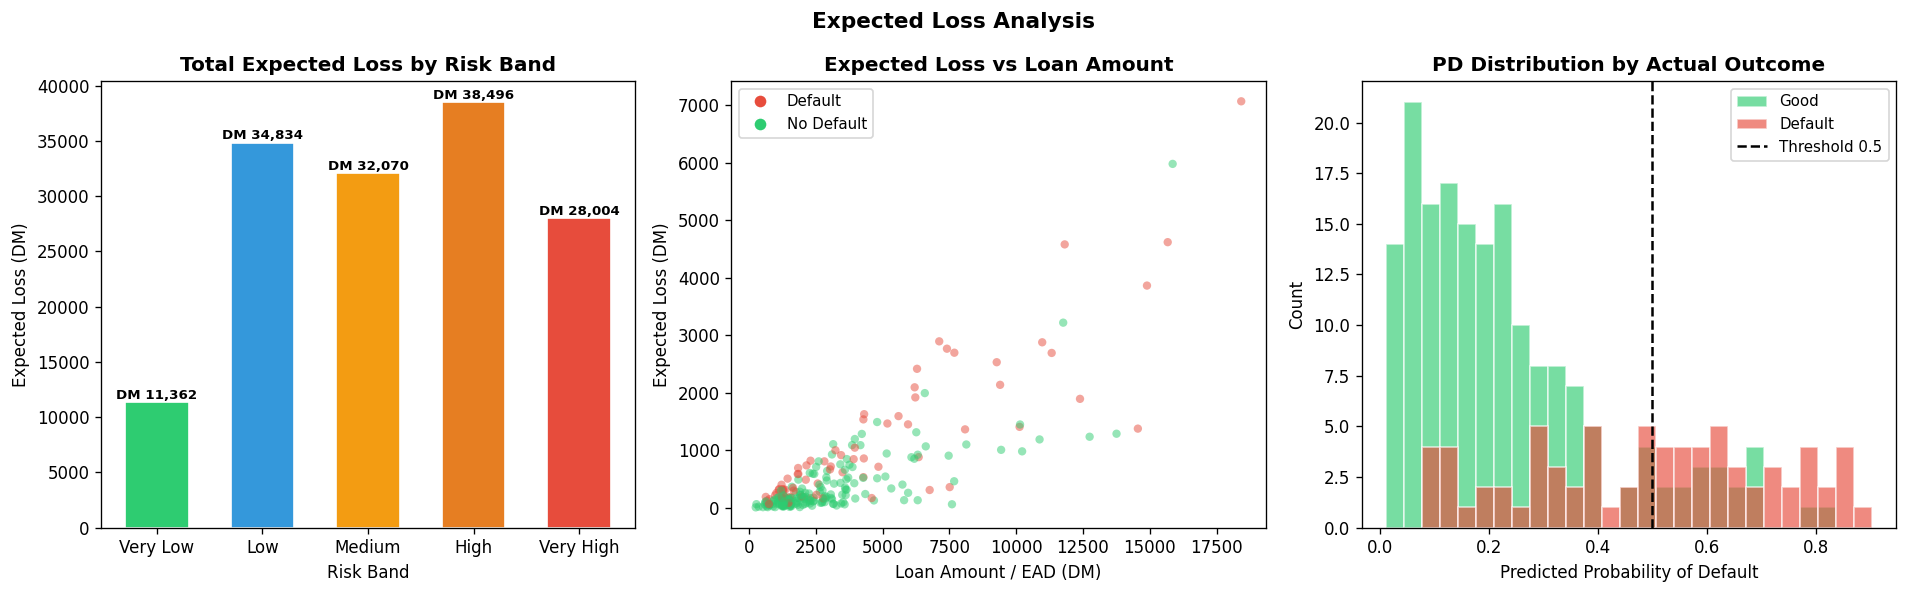

In [51]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Total Expected Loss by Risk Band
band_el = el_df.groupby('Risk_Band', observed=True)['Expected_Loss'].sum()
colors  = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
bars    = axes[0].bar(band_el.index, band_el.values,
                      color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Total Expected Loss by Risk Band', fontweight='bold')
axes[0].set_xlabel('Risk Band')
axes[0].set_ylabel('Expected Loss (DM)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 'DM ' + f'{bar.get_height():,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

# ── Plot 2: Expected Loss vs Loan Amount scatter
scatter_c = ['#e74c3c' if d == 1 else '#2ecc71' for d in el_df['Actual_Default']]
axes[1].scatter(el_df['EAD'], el_df['Expected_Loss'],
                c=scatter_c, alpha=0.5, s=25, edgecolors='none')
axes[1].set_title('Expected Loss vs Loan Amount', fontweight='bold')
axes[1].set_xlabel('Loan Amount / EAD (DM)')
axes[1].set_ylabel('Expected Loss (DM)')
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='#e74c3c', markersize=8, label='Default'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='#2ecc71', markersize=8, label='No Default'),
]
axes[1].legend(handles=legend_elements, fontsize=9)

# ── Plot 3: PD Distribution by Actual Outcome
axes[2].hist(el_df.loc[el_df['Actual_Default'] == 0, 'PD'],
             bins=25, alpha=0.65, color='#2ecc71',
             label='Good', edgecolor='white')
axes[2].hist(el_df.loc[el_df['Actual_Default'] == 1, 'PD'],
             bins=25, alpha=0.65, color='#e74c3c',
             label='Default', edgecolor='white')
axes[2].axvline(0.5, color='black', linestyle='--',
                lw=1.5, label='Threshold 0.5')
axes[2].set_title('PD Distribution by Actual Outcome', fontweight='bold')
axes[2].set_xlabel('Predicted Probability of Default')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.suptitle('Expected Loss Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get coefficients from Logistic Regression
# Positive coefficient = increases probability of default
# Negative coefficient = decreases probability of default

feature_names = X_train.columns.tolist()
coefficients  = lr.coef_[0]

importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value — biggest impact regardless of direction
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False).head(15)
importance_df = importance_df.sort_values('Coefficient', ascending=True)

print("Top 15 Most Influential Features:")
print()
print(f"{'Feature':<45} {'Coefficient':>12}")
print("-" * 60)
for _, row in importance_df.iterrows():
    direction = "↑ risk" if row['Coefficient'] > 0 else "↓ risk"
    print(f"{row['Feature']:<45} {row['Coefficient']:>10.4f}  {direction}")

Top 15 Most Influential Features:

Feature                                        Coefficient
------------------------------------------------------------
status_account                                   -0.4851  ↓ risk
other_installment_plans_none                     -0.4425  ↓ risk
status_and_sex_male : single                     -0.4107  ↓ risk
purpose_car (used)                               -0.3896  ↓ risk
status_savings                                   -0.2845  ↓ risk
secondary_obligor_guarantor                      -0.2370  ↓ risk
credit_amount                                     0.2117  ↑ risk
housing_rent                                      0.2468  ↑ risk
purpose_car (new)                                 0.2478  ↑ risk
is_foreign_worker                                 0.2711  ↑ risk
month_duration                                    0.3002  ↑ risk
payment_to_income_ratio                           0.3049  ↑ risk
collateral_savings agreement/life insurance       0.3416  ↑ risk


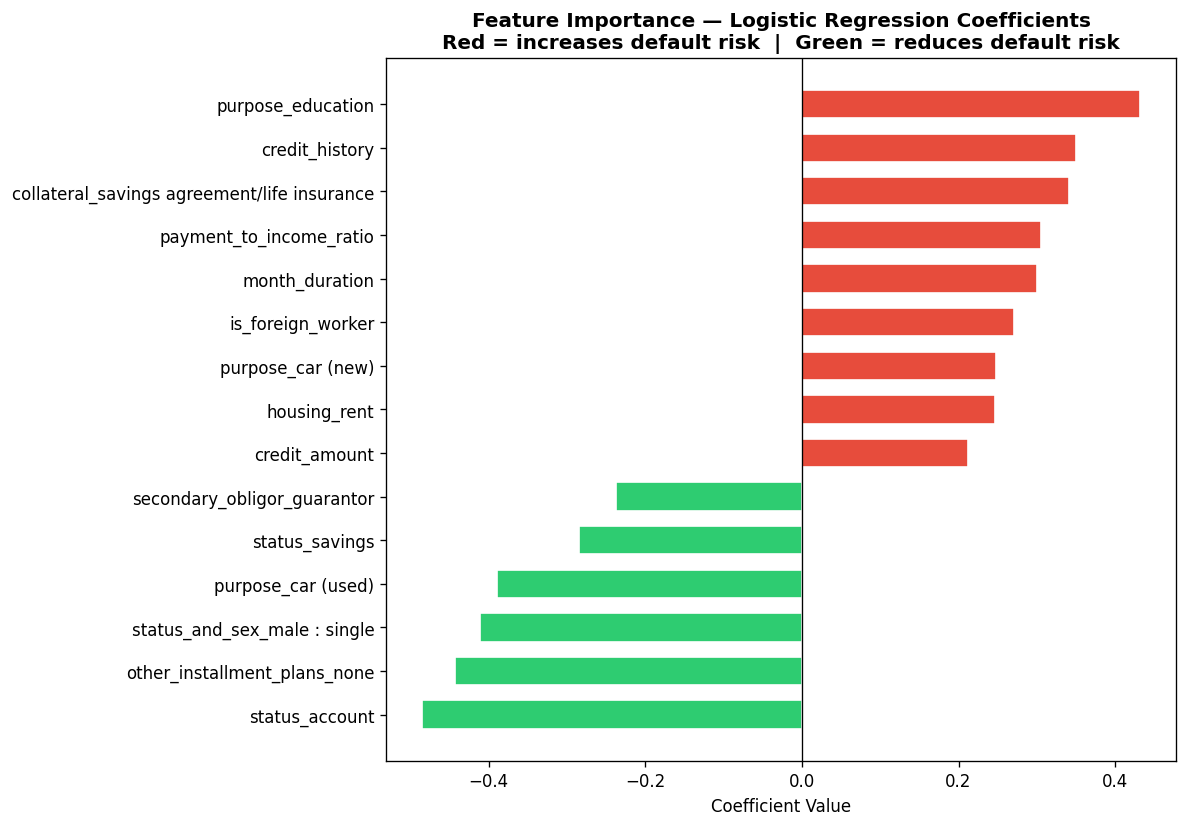

In [53]:
# ── Visualise
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['Feature'], importance_df['Coefficient'],
               color=colors, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Importance — Logistic Regression Coefficients\n'
             'Red = increases default risk  |  Green = reduces default risk',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

## Feature Importance — Business Interpretation

### Green bars — reduce default risk (good signals)

### status_account
### Higher checking account balance = strongest single signal of financial health

### other_installment_plans_none
### No other active loans = applicant is not over-leveraged

### status_and_sex_male : single
### Single males in this dataset statistically repay better

### purpose_car (used)
### Used car loans are safer — smaller amounts, borrower is price-conscious

### status_savings
### More savings = lower risk, as expected

### secondary_obligor_guarantor
### Having a guarantor backing the loan reduces risk significantly


### Red bars — increase default risk (warning signals)

### purpose_education
### Strongest risk driver — education loans have no immediate income return

### credit_history
### Counterintuitive at first, but higher ordinal score here means more complex history

### month_duration
### Longer loan tenure = more time for things to go wrong

### payment_to_income_ratio
### Higher installment as % of income = borrower is stretched thin

### is_foreign_worker
## Foreign workers in this 1990s German dataset had higher default rates

### housing_rent
### Renters have less financial stability than homeowners

## Predicting a New Client

In [8]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════
#  STEP 1 — Rebuild the model (runs in seconds)
# ═══════════════════════════════════════════════════════

df = pd.read_csv('german_credit_data.csv')
df['target'] = df['target'].map({'good': 0, 'bad': 1})

ordinal_mappings = {
    'status_account'  : ['< 0 DM', '0 to < 200 DM',
                         '>= 200 DM', 'no checking account'],
    'status_savings'  : ['< 100 DM', '100 to < 500 DM',
                         '500 to < 1000 DM', '>= 1000 DM',
                         'unknown/ no savings account'],
    'years_employment': ['unemployed', '< 1 year', '1 to < 4 years',
                         '4 to < 7 years', '>= 7 years'],
    'credit_history'  : [
        'critical account/ other credits existing (not at this bank)',
        'delay in paying off in the past',
        'existing credits paid back duly till now',
        'all credits at this bank paid back duly',
        'no credits taken/ all credits paid back duly'
    ]
}

for col, order in ordinal_mappings.items():
    df[col] = df[col].map({val: i for i, val in enumerate(order)})

df['telephone'] = df['telephone'].map(
    {'yes, registered under the customers name': 1, 'none': 0})
df['is_foreign_worker'] = df['is_foreign_worker'].map(
    {'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=[
    'purpose', 'status_and_sex', 'secondary_obligor',
    'collateral', 'other_installment_plans', 'housing', 'job'
], drop_first=True)

numeric_cols = ['age', 'credit_amount', 'month_duration',
                'payment_to_income_ratio', 'residence_since',
                'n_credits', 'n_guarantors']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

lr = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr.fit(X_train, y_train)


# ═══════════════════════════════════════════════════════
#  STEP 2 — Define the prediction function
# ═══════════════════════════════════════════════════════

def assess_client(client_dict):

    df_c = pd.DataFrame([client_dict])

    # Ordinal encoding
    for col, order in ordinal_mappings.items():
        mapping = {val: i for i, val in enumerate(order)}
        df_c[col] = df_c[col].map(mapping)

    # Binary encoding
    df_c['telephone'] = df_c['telephone'].map(
        {'yes, registered under the customers name': 1, 'none': 0})
    df_c['is_foreign_worker'] = df_c['is_foreign_worker'].map(
        {'yes': 1, 'no': 0})

    # One-hot encoding
    df_c = pd.get_dummies(df_c, columns=[
        'purpose', 'status_and_sex', 'secondary_obligor',
        'collateral', 'other_installment_plans', 'housing', 'job'
    ])

    # Align columns to training set — fills missing columns with 0
    df_c = df_c.reindex(columns=X_train.columns, fill_value=0)

    # Scale numeric columns using the SAME scaler from training
    df_c[numeric_cols] = scaler.transform(df_c[numeric_cols])

    # Predict
    PD  = lr.predict_proba(df_c)[0][1]
    EAD = client_dict['credit_amount']
    LGD = 0.45
    EL  = PD * LGD * EAD

    if   PD <= 0.20: band = "Very Low"
    elif PD <= 0.40: band = "Low"
    elif PD <= 0.60: band = "Medium"
    elif PD <= 0.80: band = "High"
    else:            band = "Very High"

    if   PD < 0.35: decision = "APPROVE"
    elif PD < 0.60: decision = "REFER FOR REVIEW"
    else:           decision = "DECLINE"

    print("=" * 50)
    print(" CLIENT CREDIT ASSESSMENT")
    print("=" * 50)
    print("Probability of Default :", str(round(PD * 100, 2)) + "%")
    print("Risk Band              :", band)
    print("Loan Amount (EAD)      :", "DM", f"{EAD:,.0f}")
    print("Loss Given Default     :", "45%")
    print("Expected Loss          :", "DM", f"{EL:,.2f}")
    print("Decision               :", decision)
    print("=" * 50)

# ══════════════════════════════════════════════════════
#  STEP 3 — Fill in your new client and run
# ══════════════════════════════════════════════════════

new_client = {
    'status_account'          : '0 to < 200 DM',
    'month_duration'          : 24,
    'credit_history'          : 'existing credits paid back duly till now',
    'purpose'                 : 'furniture/equipment',
    'credit_amount'           : 5000,
    'status_savings'          : '100 to < 500 DM',
    'years_employment'        : '1 to < 4 years',
    'payment_to_income_ratio' : 3,
    'status_and_sex'          : 'male : single',
    'secondary_obligor'       : 'none',
    'residence_since'         : 2,
    'collateral'              : 'none',
    'age'                     : 32,
    'other_installment_plans' : 'none',
    'housing'                 : 'own',
    'n_credits'               : 1,
    'job'                     : 'skilled employee/ official',
    'n_guarantors'            : 1,
    'telephone'               : 'yes, registered under the customers name',
    'is_foreign_worker'       : 'yes'
}

assess_client(new_client)

 CLIENT CREDIT ASSESSMENT
Probability of Default : 25.36%
Risk Band              : Low
Loan Amount (EAD)      : DM 5,000
Loss Given Default     : 45%
Expected Loss          : DM 570.58
Decision               : APPROVE
